# Hypotes 2: Boarea och utgångspris

**Hypotes:** Större boarea hänger samman med högre utgångspris.

**Syfte:** Undersöka sambandet mellan boarea och utgångspris,
både för alla bostäder tillsammans och uppdelat efter bostadstyp.

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split

# Läs in data

In [110]:
df_original = pd.read_csv(
    "../data/SwedenHousingPrices.csv",
    encoding="utf-8-sig"
)

# Skapa en kopia för analysen
df = df_original.copy()

# Visa kolumnerna som behövs för hypotesen
df[["living_area_sqm", "asking_price_sek", "typology"]].head()

,living_area_sqm,asking_price_sek,typology
0,82.0,3695000.0,APARTMENT
1,109.0,3095000.0,APARTMENT
2,54.0,2295000.0,APARTMENT
3,119.0,3675000.0,APARTMENT
4,99.0,295000.0,APARTMENT


# Första undersökning av data

In [111]:
columns = ["living_area_sqm", "asking_price_sek", "number_rooms"]

Kontrollera antal rader och datatyper

In [112]:
print("Antal rader:", len(df))
print(df[columns].dtypes)

Antal rader: 11549
living_area_sqm     float64
asking_price_sek    float64
number_rooms        float64
dtype: object


In [113]:
print("\nSaknade värden:")
print(df[columns].isna().sum())

print("\nNoll eller negativa värden:")
print((df[columns] <= 0).sum())



Saknade värden:
living_area_sqm     0
asking_price_sek    0
number_rooms        0
dtype: int64

Noll eller negativa värden:
living_area_sqm     311
asking_price_sek      0
number_rooms        447
dtype: int64


Kontrollera vilka bostadstyper som finns

In [114]:
print("\nBostadstyper:")
print(df["typology"].value_counts(dropna=False))
df["typology"].isna().sum()


Bostadstyper:
typology
APARTMENT                     7269
HOUSE                         2647
ROW_HOUSE                      590
PLOT                           237
TWIN_HOUSE                     187
VACATION_HOUSE                 165
LINKED_HOUSE                   118
WINTERIZED_VACATION_HOME        84
OTHER                           79
TERRACED_HOUSE                  58
HOMESTEAD                       50
ESTATE_WITHOUT_CULTIVATION      25
AGRICULTURAL_ESTATE             21
FORESTING_ESTATE                11
VACATION_HOME                    8
Name: count, dtype: int64


np.int64(0)

# Datarensning och urval

Välj bostadstyper och förbered kolumner

In [115]:
allowed_typologies = ["APARTMENT", "HOUSE", "ROW_HOUSE"]

# Behåll samma bostadstyper som gruppen
df_prepared = df_original[df_original["typology"].isin(allowed_typologies)].copy()

# Dela upp koordinaterna i två numeriska kolumner
df_prepared[["latitude", "longitude"]] = ( df_prepared["coordenates"].str.split(",", expand=True).astype(float))

# Hämta kommunen från sista delen av location
df_prepared["municipality"] = (df_prepared["location"].str.split(", ").str[-1].str.strip())

df_prepared[["typology", "municipality", "latitude", "longitude"]].head()

,typology,municipality,latitude,longitude
0,APARTMENT,Malmö kommun,55.611843,12.982288
1,APARTMENT,Lunds kommun,55.723007,13.197303
2,APARTMENT,Sundbybergs kommun,59.381943,17.973993
3,APARTMENT,Alingsås kommun,57.931110,12.536900
4,APARTMENT,Skara kommun,58.382830,13.419069


Grundläggande datarensning och prisurval

In [116]:
df_clean = df_prepared[
    df_prepared["asking_price_sek"].between(100_000, 10_000_000) & (df_prepared["living_area_sqm"] > 0) & (df_prepared["number_rooms"] > 0) & df_prepared["latitude"].between(55.0, 69.1) & df_prepared["longitude"].between(10.5, 24.2) ].copy()

Avgränsningar per bostadstyp

In [117]:
apartment_mask = (
    (df_clean["typology"] == "APARTMENT")
    & df_clean["living_area_sqm"].between(10, 300)
    & df_clean["number_rooms"].between(1, 10)
)

house_mask = (
    (df_clean["typology"] == "HOUSE")
    & df_clean["living_area_sqm"].between(25, 400)
    & df_clean["number_rooms"].between(1, 15)
    & (df_clean["land_area_sqm"] <= 4_000)
)

row_house_mask = (
    (df_clean["typology"] == "ROW_HOUSE")
    & df_clean["living_area_sqm"].between(40, 300)
    & df_clean["number_rooms"].between(1, 10)
)

df_clean = df_clean[
    apartment_mask | house_mask | row_house_mask
].copy()

Kontrollera hur många rader som finns kvar

In [118]:
print("Före rensning:", len(df))
print("Efter rensning:", len(df_clean))
print("Borttagna rader:", len(df) - len(df_clean))

print("\nBostadstyper efter rensning:")
print(df_clean["typology"].value_counts())

Före rensning: 11549
Efter rensning: 10090
Borttagna rader: 1459

Bostadstyper efter rensning:
typology
APARTMENT    7199
HOUSE        2313
ROW_HOUSE     578
Name: count, dtype: int64


Förbered tomtarea för modellering

In [119]:
# Skapa en kopia för modelleringen
df_model = df_clean.copy()

# Markera om den ursprungliga tomtarean är positiv
df_model["has_land_area"] = (df_model["land_area_sqm"] > 0).astype(int)

# Använd samma regler för tomtarea som gruppen
df_model.loc[ df_model["typology"] == "APARTMENT", "land_area_sqm"] = np.nan

df_model.loc[ (df_model["typology"] == "HOUSE") & (df_model["land_area_sqm"] < 50), "land_area_sqm"] = np.nan

df_model[ ["typology", "land_area_sqm", "has_land_area"] ].head()

,typology,land_area_sqm,has_land_area
0,APARTMENT,NaN,0
1,APARTMENT,NaN,0
2,APARTMENT,NaN,0
3,APARTMENT,NaN,0
4,APARTMENT,NaN,0


# Dela upp data i träning, validering och test

In [120]:
# Lägg undan 20 % för slutlig testning
train_validation_df, test_df = train_test_split( df_model, test_size=0.2, random_state=42, stratify=df_model["typology"])

# 25 % av återstående 80 % blir 20 % av hela datamängden
train_df, validation_df = train_test_split( train_validation_df, test_size=0.25, random_state=42, stratify=train_validation_df["typology"])

print("Träning:", len(train_df))
print("Validering:", len(validation_df))
print("Test:", len(test_df))

Träning: 6054
Validering: 2018
Test: 2018


# EDA, samband mellan boarea och utgångspris

In [121]:
# Beräkna korrelationen på träningsdata
correlation = train_df["living_area_sqm"].corr(train_df["asking_price_sek"], method="pearson")

print("Pearsons korrelation i träningsdata:", round(correlation, 3))

Pearsons korrelation i träningsdata: 0.424


Visa sambandet mellan boarea och utgångspris

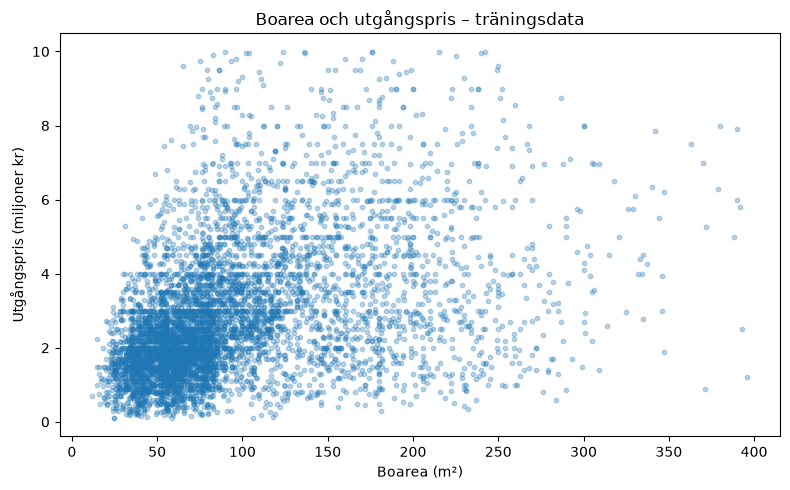

In [122]:
plt.figure(figsize=(8, 5))

plt.scatter(
    train_df["living_area_sqm"],
    train_df["asking_price_sek"] / 1_000_000,
    alpha=0.3,
    s=10
)

plt.xlabel("Boarea (m²)")
plt.ylabel("Utgångspris (miljoner kr)")
plt.title("Boarea och utgångspris – träningsdata")

plt.tight_layout()
plt.show()

# Analys per bostadstyp

In [123]:
# Beräkna korrelationen per bostadstyp i träningsdata
for housing_type, group in train_df.groupby("typology"):
    group_correlation = group["living_area_sqm"].corr(
        group["asking_price_sek"],
        method="pearson"
    )

    print(
        f"{housing_type}: {len(group)} bostäder, "
        f"Pearsons korrelation: {group_correlation:.3f}"
    )

APARTMENT: 4319 bostäder, Pearsons korrelation: 0.439
HOUSE: 1388 bostäder, Pearsons korrelation: 0.211
ROW_HOUSE: 347 bostäder, Pearsons korrelation: 0.369


Visa ett separat diagram för varje bostadstyp

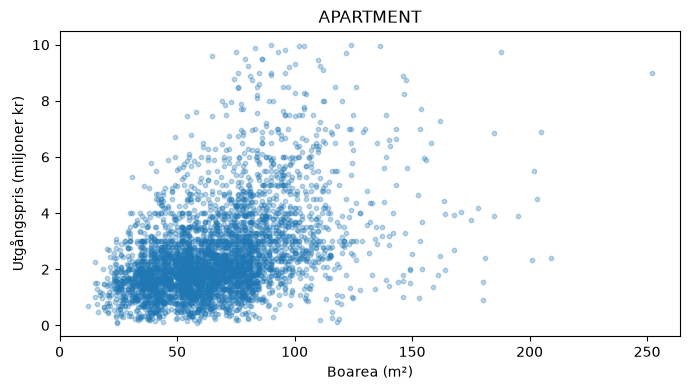

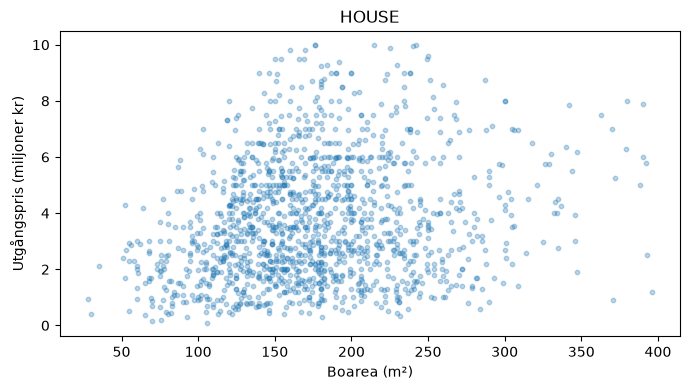

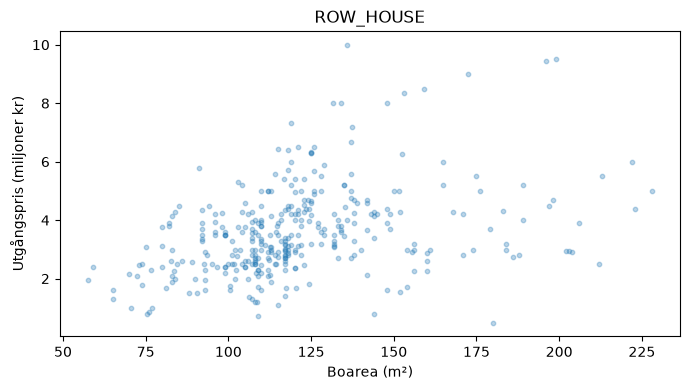

In [124]:
for housing_type, group in train_df.groupby("typology"):
    plt.figure(figsize=(7, 4))

    plt.scatter(
        group["living_area_sqm"],
        group["asking_price_sek"] / 1_000_000,
        alpha=0.3,
        s=10
    )

    plt.xlabel("Boarea (m²)")
    plt.ylabel("Utgångspris (miljoner kr)")
    plt.title(housing_type)
    plt.tight_layout()
    plt.show()

# Kompletterande analys , rangkorrelation

In [125]:
for housing_type, group in train_df.groupby("typology"):
    pearson = group["living_area_sqm"].corr(
        group["asking_price_sek"]
    )
    spearman = group["living_area_sqm"].corr(
        group["asking_price_sek"],
        method="spearman"
    )

    print(
        f"{housing_type}: "
        f"Pearson = {pearson:.3f}, "
        f"Spearman = {spearman:.3f}"
    )

APARTMENT: Pearson = 0.439, Spearman = 0.422
HOUSE: Pearson = 0.211, Spearman = 0.201
ROW_HOUSE: Pearson = 0.369, Spearman = 0.427


# Slutsats och begränsningar

Analysen bygger på 6 054 bostäder i träningsdata. Pearsons
korrelation mellan boarea och utgångspris var 0,424. Sambandet
var positivt även inom varje bostadstyp: 0,439 för lägenheter,
0,211 för hus och 0,369 för radhus. Även Spearmans korrelation
var positiv för alla tre bostadstyperna.

Resultaten stödjer hypotesen att större boarea hänger samman
med högre utgångspris i vårt urval. Samtidigt visar diagrammen
att bostäder med liknande boarea kan ha väldigt olika priser.
Därför räcker boarea ensam inte för att förklara priset.

Här har jag jämfört bostadstyperna, medan geografiskt läge
undersöks i gruppens andra hypotes. Jag har alltså inte undersökt
sambandet inom samma område. Resultaten gäller vårt filtrerade
urval och utgångspriser, inte slutpriser. De visar ett samband
men bevisar inte att större boarea i sig orsakar ett högre pris.

En första analys gjordes på hela datamängden före uppdelningen,
så testdata har inte varit helt osedda.

Nästa steg är att jämföra samma modell med och utan boarea på
valideringsdata för att se om boarea minskar prediktionsfelet.